## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
})
PALETTE = ['#2C5F8A', '#E8743B', '#4CAF93', '#C44E52', '#8C6BB1']
sns.set_palette(PALETTE)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

df = pd.read_csv('data/sales_data.csv')
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
print(f"Shape: {df.shape}")
df.head()

Shape: (2000, 14)


,OrderDate,Category,Region,CustomerSegment,Channel,Price,Quantity,Discount,Revenue,Rating,Age,Month,Quarter,Year
0,2024-01-01,Home & Garden,South,Returning,Mobile App,77.600,4,0.000,310.400,4.400,43,2024-01,2024Q1,2024
1,2024-01-01,Sports,Central,New,Online,258.750,3,0.000,776.250,4.000,18,2024-01,2024Q1,2024
2,2024-01-01,Home & Garden,East,New,Mobile App,410.730,4,0.150,"1,396.480",3.000,62,2024-01,2024Q1,2024
3,2024-01-01,Electronics,East,New,Mobile App,142.810,5,0.000,714.050,4.200,21,2024-01,2024Q1,2024
4,2024-01-01,Home & Garden,North,Returning,In-Store,346.950,4,0.000,"1,387.800",3.500,46,2024-01,2024Q1,2024


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderDate        2000 non-null   datetime64[ns]
 1   Category         2000 non-null   object        
 2   Region           2000 non-null   object        
 3   CustomerSegment  2000 non-null   object        
 4   Channel          2000 non-null   object        
 5   Price            2000 non-null   float64       
 6   Quantity         2000 non-null   int64         
 7   Discount         2000 non-null   float64       
 8   Revenue          2000 non-null   float64       
 9   Rating           2000 non-null   float64       
 10  Age              2000 non-null   int64         
 11  Month            2000 non-null   object        
 12  Quarter          2000 non-null   object        
 13  Year             2000 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(

## Day 1 — Descriptive Statistics

Calculating mean, median, mode, standard deviation, variance, skewness, and kurtosis for all numeric variables.

In [3]:
numeric_cols = ['Price', 'Quantity', 'Discount', 'Revenue', 'Rating', 'Age']

desc = pd.DataFrame(index=numeric_cols)
for c in numeric_cols:
    s = df[c]
    desc.loc[c, 'mean']      = s.mean()
    desc.loc[c, 'median']    = s.median()
    desc.loc[c, 'mode']      = s.mode().iloc[0]
    desc.loc[c, 'std']       = s.std()
    desc.loc[c, 'variance']  = s.var()
    desc.loc[c, 'min']       = s.min()
    desc.loc[c, 'max']       = s.max()
    desc.loc[c, 'range']     = s.max() - s.min()
    desc.loc[c, 'skewness']  = s.skew()
    desc.loc[c, 'kurtosis']  = s.kurtosis()
    desc.loc[c, 'cv_%']      = (s.std() / s.mean()) * 100

desc.round(3)

,mean,median,mode,std,variance,min,max,range,skewness,kurtosis,cv_%
Price,268.059,158.420,35.960,289.453,"83,783.137",5.010,"1,199.880","1,194.870",1.610,1.739,107.981
Quantity,3.010,3.000,4.000,1.414,1.999,1.000,5.000,4.000,-0.017,-1.307,46.985
Discount,0.043,0.000,0.000,0.063,0.004,0.000,0.200,0.200,1.252,0.222,146.974
Revenue,774.187,397.755,20.150,993.693,"987,425.687",4.800,"5,946.650","5,941.850",2.354,6.045,128.353
Rating,3.651,3.700,3.900,0.704,0.496,1.200,5.000,3.800,-0.129,-0.391,19.281
Age,38.152,38.000,18.000,12.156,147.771,18.000,75.000,57.000,0.206,-0.531,31.862


In [4]:
print(f"Total Revenue: ${df['Revenue'].sum():,.2f}")
print(f"Number of orders: {len(df):,}")
print(f"Date range: {df['OrderDate'].min().date()} to {df['OrderDate'].max().date()}")
print(f"Average order value: ${df['Revenue'].mean():,.2f}")

Total Revenue: $1,548,374.62
Number of orders: 2,000
Date range: 2024-01-01 to 2025-12-31
Average order value: $774.19


**Interpretation:**
- Revenue is right-skewed (skew ≈ 2.35) — most orders are modest, with a long tail of large, high-value orders (driven mainly by Electronics).
- Price shows similar right-skew (≈1.61), consistent with a product mix spanning Books (~$20) to Electronics (~$1000+).
- Quantity and Rating are close to symmetric, near their respective central tendencies.
- High coefficient of variation (CV) for Revenue (128%) confirms substantial spread relative to the mean — a single average figure understates the real variability in order value.

## Day 2 — Data Distribution Analysis

Testing whether Revenue and Price follow a normal distribution using the Shapiro-Wilk and D'Agostino-Pearson tests, supported by histograms and Q-Q plots.

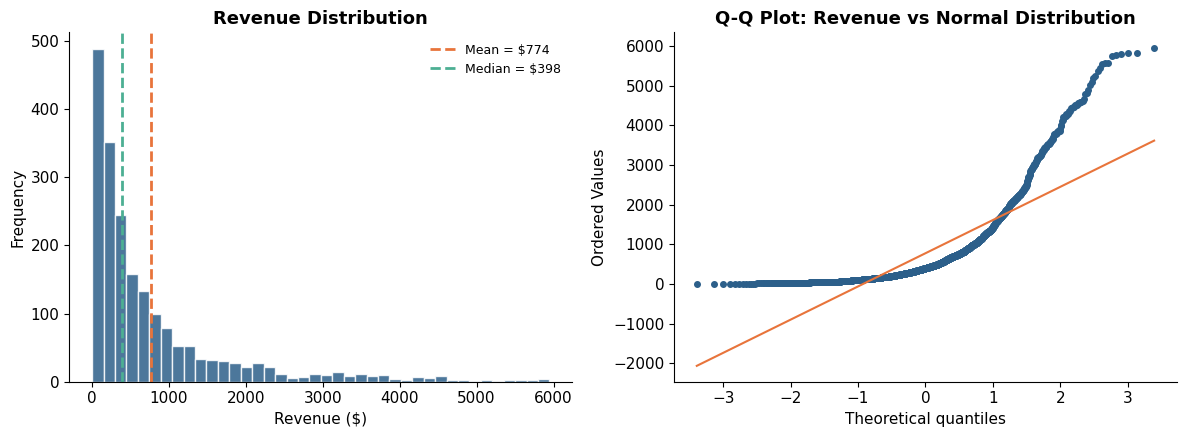

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df['Revenue'], bins=40, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].axvline(df['Revenue'].mean(), color=PALETTE[1], linestyle='--', linewidth=2,
                 label=f"Mean = ${df['Revenue'].mean():,.0f}")
axes[0].axvline(df['Revenue'].median(), color=PALETTE[2], linestyle='--', linewidth=2,
                 label=f"Median = ${df['Revenue'].median():,.0f}")
axes[0].set_title('Revenue Distribution')
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend(frameon=False, fontsize=9)

stats.probplot(df['Revenue'], dist='norm', plot=axes[1])
axes[1].get_lines()[0].set_color(PALETTE[0]); axes[1].get_lines()[0].set_markersize(4)
axes[1].get_lines()[1].set_color(PALETTE[1])
axes[1].set_title('Q-Q Plot: Revenue vs Normal Distribution')
plt.tight_layout()
plt.savefig('figures/01_revenue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Shapiro-Wilk and D'Agostino normality tests
alpha = 0.05
for col in ['Revenue', 'Price']:
    s = df[col]
    sample = s.sample(min(len(s), 5000), random_state=42)
    sh_stat, sh_p = stats.shapiro(sample)
    da_stat, da_p = stats.normaltest(s)
    print(f"--- {col} ---")
    print(f"  Shapiro-Wilk:        stat={sh_stat:.4f}, p={sh_p:.6f}  -> {'Normal' if sh_p>alpha else 'NOT normal'}")
    print(f"  D'Agostino K-squared: stat={da_stat:.4f}, p={da_p:.6f}  -> {'Normal' if da_p>alpha else 'NOT normal'}")
    print(f"  Skewness={s.skew():.3f}, Kurtosis={s.kurtosis():.3f}\n")

--- Revenue ---
  Shapiro-Wilk:        stat=0.7085, p=0.000000  -> NOT normal
  D'Agostino K-squared: stat=973.7253, p=0.000000  -> NOT normal
  Skewness=2.354, Kurtosis=6.045

--- Price ---
  Shapiro-Wilk:        stat=0.7799, p=0.000000  -> NOT normal
  D'Agostino K-squared: stat=541.3786, p=0.000000  -> NOT normal
  Skewness=1.610, Kurtosis=1.739



**Interpretation:** Both Shapiro-Wilk and D'Agostino tests reject normality for Revenue and Price (p < 0.001). This is expected for transaction-level revenue/price data, which is typically right-skewed and bounded at zero. **Practical implication:** because n = 2,000 is large, the Central Limit Theorem still lets us use t-tests/ANOVA safely for *means* (sampling distributions of the mean converge to normal regardless), but any analysis assuming normality of the *raw* values (e.g., certain parametric outlier rules) should account for this skew.

## Day 3 — Correlation Analysis

Pearson correlation matrix across all numeric variables, with significance testing for the most business-relevant pairs.

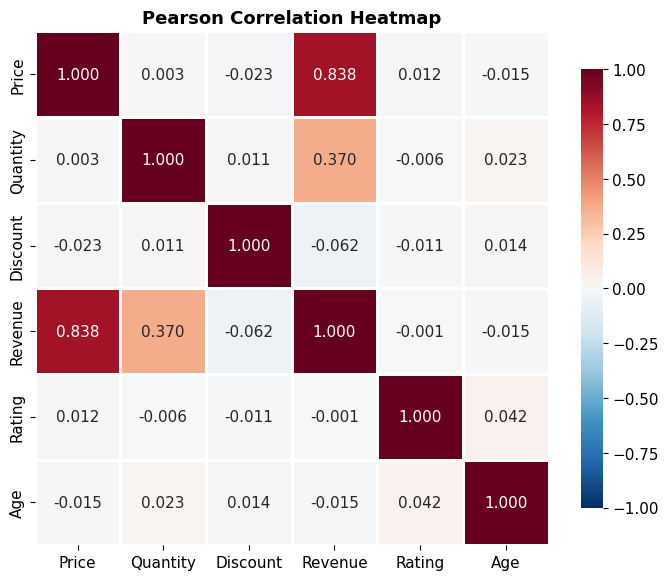

In [7]:
corr_matrix = df[numeric_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=1, linecolor='white', cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.savefig('figures/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
pairs = [('Price','Revenue'), ('Quantity','Revenue'), ('Discount','Revenue'),
         ('Price','Quantity'), ('Rating','Revenue'), ('Age','Revenue')]

print(f"{'Pair':<22}{'r':>8}{'p-value':>14}  Strength / Significance")
print('-'*75)
for a, b in pairs:
    r, p = stats.pearsonr(df[a], df[b])
    strength = ('Very strong' if abs(r)>=0.8 else 'Strong' if abs(r)>=0.6 else
                'Moderate' if abs(r)>=0.4 else 'Weak' if abs(r)>=0.2 else 'Very weak/None')
    sig = 'SIGNIFICANT' if p < 0.05 else 'not significant'
    print(f"{a+' vs '+b:<22}{r:>8.4f}{p:>14.2g}  [{strength}, {sig}]")

Pair                         r       p-value  Strength / Significance
---------------------------------------------------------------------------
Price vs Revenue        0.8376             0  [Very strong, SIGNIFICANT]
Quantity vs Revenue     0.3696       9.4e-66  [Weak, SIGNIFICANT]
Discount vs Revenue    -0.0620        0.0056  [Very weak/None, SIGNIFICANT]
Price vs Quantity       0.0035          0.88  [Very weak/None, not significant]
Rating vs Revenue      -0.0010          0.96  [Very weak/None, not significant]
Age vs Revenue         -0.0153          0.49  [Very weak/None, not significant]


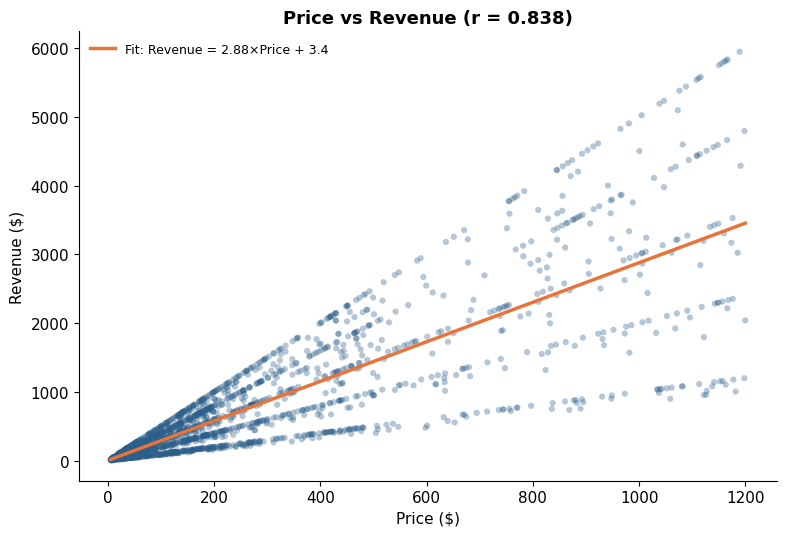

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(df['Price'], df['Revenue'], alpha=0.35, s=20, color=PALETTE[0], edgecolors='none')
z = np.polyfit(df['Price'], df['Revenue'], 1)
xline = np.linspace(df['Price'].min(), df['Price'].max(), 100)
ax.plot(xline, z[0]*xline + z[1], color=PALETTE[1], linewidth=2.5,
        label=f'Fit: Revenue = {z[0]:.2f}×Price + {z[1]:.1f}')
r, p = stats.pearsonr(df['Price'], df['Revenue'])
ax.set_title(f'Price vs Revenue (r = {r:.3f})')
ax.set_xlabel('Price ($)'); ax.set_ylabel('Revenue ($)')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('figures/04_price_vs_revenue_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**
- **Price ↔ Revenue: r = 0.838 (very strong, p < 0.001).** This is the dominant relationship in the dataset — unsurprising since Revenue = Price × Quantity × (1 − Discount), but it confirms pricing strategy is the single biggest lever on order value.
- **Quantity ↔ Revenue: r = 0.370 (weak-to-moderate, p < 0.001).** Quantity matters, but far less than price tier.
- **Discount ↔ Revenue: r = −0.062 (very weak, but statistically significant given n=2000).** Discounting shows a slight negative association with revenue — discounts are not meaningfully driving up order value in this dataset.
- Rating and Age show essentially no linear relationship with Revenue.

## Day 4 — Hypothesis Testing

Five hypothesis tests covering ANOVA, t-tests, and a chi-square test of independence — exceeding the minimum requirement of 3.

### Test 1: One-Way ANOVA — Revenue across Sales Channels

In [10]:
channels = df['Channel'].unique()
groups_ch = [df.loc[df['Channel']==ch, 'Revenue'] for ch in channels]

f_stat, p_val = stats.f_oneway(*groups_ch)
lev_stat, lev_p = stats.levene(*groups_ch)

grand_mean = df['Revenue'].mean()
ss_between = sum(len(g)*(g.mean()-grand_mean)**2 for g in groups_ch)
ss_total = sum((df['Revenue']-grand_mean)**2)
eta_sq = ss_between/ss_total

print("H0: Mean revenue is equal across Mobile App, Online, and In-Store channels")
print("H1: At least one channel's mean revenue differs\n")
for ch in channels:
    g = df.loc[df['Channel']==ch, 'Revenue']
    print(f"  {ch:<12} n={len(g):>4}  mean=${g.mean():>8.2f}  std=${g.std():>8.2f}")
print(f"\nF-statistic = {f_stat:.4f}, p-value = {p_val:.4f}")
print(f"Levene's test (variance homogeneity): p={lev_p:.4f} -> {'OK' if lev_p>0.05 else 'violated'}")
print(f"Eta-squared (effect size) = {eta_sq:.4f}")
print(f"\nDecision: {'REJECT H0' if p_val < 0.05 else 'FAIL TO REJECT H0'} at alpha = 0.05")

H0: Mean revenue is equal across Mobile App, Online, and In-Store channels
H1: At least one channel's mean revenue differs

  Mobile App   n= 379  mean=$  808.71  std=$  993.21
  Online       n=1012  mean=$  778.99  std=$ 1010.95
  In-Store     n= 609  mean=$  744.73  std=$  965.44

F-statistic = 0.5079, p-value = 0.6019
Levene's test (variance homogeneity): p=0.4911 -> OK
Eta-squared (effect size) = 0.0005

Decision: FAIL TO REJECT H0 at alpha = 0.05


**Conclusion:** With p = 0.602, we fail to reject H0. There is **no statistically significant difference** in mean revenue across Mobile App, Online, and In-Store channels. The near-zero eta-squared (0.0005) confirms channel explains almost none of the variance in revenue — customers spend similarly regardless of how they shop.

### Test 2: One-Way ANOVA — Revenue across Product Categories

In [11]:
cats = df['Category'].unique()
groups_cat = [df.loc[df['Category']==c, 'Revenue'] for c in cats]

f_stat2, p_val2 = stats.f_oneway(*groups_cat)
ss_between2 = sum(len(g)*(g.mean()-grand_mean)**2 for g in groups_cat)
eta_sq2 = ss_between2/ss_total

print("H0: Mean revenue is equal across all 5 product categories")
print("H1: At least one category's mean revenue differs\n")
for c in cats:
    g = df.loc[df['Category']==c, 'Revenue']
    print(f"  {c:<14} n={len(g):>4}  mean=${g.mean():>8.2f}  std=${g.std():>8.2f}")
print(f"\nF-statistic = {f_stat2:.4f}, p-value = {p_val2:.4g}")
print(f"Eta-squared (effect size) = {eta_sq2:.4f}")
print(f"\nDecision: {'REJECT H0' if p_val2 < 0.05 else 'FAIL TO REJECT H0'} at alpha = 0.05")

H0: Mean revenue is equal across all 5 product categories
H1: At least one category's mean revenue differs

  Home & Garden  n= 407  mean=$  790.93  std=$  586.12
  Sports         n= 294  mean=$  419.98  std=$  336.73
  Electronics    n= 512  mean=$ 1788.73  std=$ 1381.94
  Books          n= 290  mean=$   90.50  std=$   67.60
  Clothing       n= 497  mean=$  323.78  std=$  218.04

F-statistic = 340.1736, p-value = 2.153e-223
Eta-squared (effect size) = 0.4055

Decision: REJECT H0 at alpha = 0.05


In [12]:
tukey = pairwise_tukeyhsd(df['Revenue'], df['Category'], alpha=0.05)
print(tukey.summary())

           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
    group1        group2     meandiff  p-adj    lower      upper    reject
--------------------------------------------------------------------------
        Books      Clothing    233.272 0.0004    78.5388   388.0052   True
        Books   Electronics  1698.2261    0.0  1544.3304  1852.1219   True
        Books Home & Garden   700.4213    0.0   539.5074   861.3351   True
        Books        Sports   329.4803    0.0   156.1769   502.7837   True
     Clothing   Electronics  1464.9541    0.0  1333.0964  1596.8119   True
     Clothing Home & Garden   467.1493    0.0   327.1641   607.1345   True
     Clothing        Sports    96.2083 0.4311   -57.8587   250.2753  False
  Electronics Home & Garden  -997.8049    0.0 -1136.8638  -858.7459   True
  Electronics        Sports -1368.7459    0.0 -1521.9718 -1215.5199   True
Home & Garden        Sports   -370.941    0.0  -531.2144  -210.6676   True
-------------------------

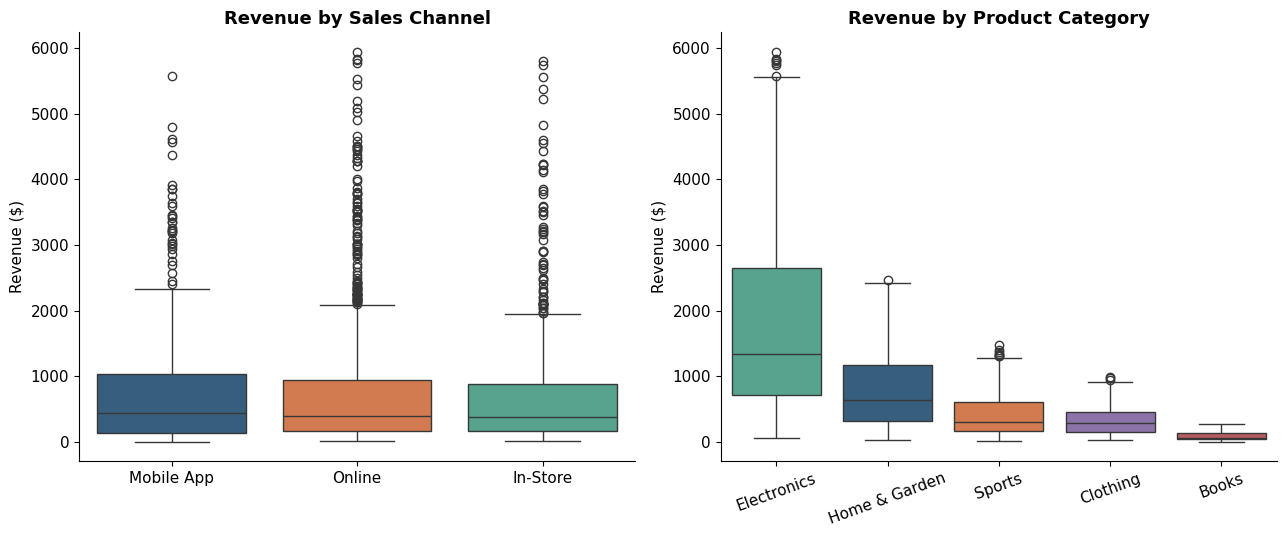

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
order_ch = df.groupby('Channel')['Revenue'].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x='Channel', y='Revenue', order=order_ch, hue='Channel',
            legend=False, ax=axes[0], palette=PALETTE[:3])
axes[0].set_title('Revenue by Sales Channel'); axes[0].set_xlabel(''); axes[0].set_ylabel('Revenue ($)')

order_cat = df.groupby('Category')['Revenue'].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x='Category', y='Revenue', order=order_cat, hue='Category',
            legend=False, ax=axes[1], palette=PALETTE)
axes[1].set_title('Revenue by Product Category'); axes[1].set_xlabel(''); axes[1].set_ylabel('Revenue ($)')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('figures/05_revenue_by_channel_category.png', dpi=150, bbox_inches='tight')
plt.show()

**Conclusion:** With p ≈ 2.15 × 10⁻²²³, we strongly reject H0. Product category has a **highly significant** effect on revenue, and eta-squared = 0.406 means category explains ~41% of all revenue variance — by far the strongest categorical driver in the dataset. The Tukey HSD post-hoc test confirms Electronics is significantly higher than every other category, and all pairs are significantly different *except* Clothing vs Sports.

### Test 3: Independent Samples t-test (Welch's) — Online vs In-Store Revenue

In [14]:
online  = df.loc[df['Channel']=='Online',  'Revenue']
instore = df.loc[df['Channel']=='In-Store', 'Revenue']

t_stat, t_p = stats.ttest_ind(online, instore, equal_var=False)
pooled_sd = np.sqrt(((len(online)-1)*online.std()**2 + (len(instore)-1)*instore.std()**2)
                     / (len(online)+len(instore)-2))
cohens_d = (online.mean()-instore.mean())/pooled_sd

print("H0: Mean revenue (Online) = Mean revenue (In-Store)")
print("H1: Mean revenue (Online) != Mean revenue (In-Store)\n")
print(f"Online:    n={len(online):>4}  mean=${online.mean():>8.2f}  std=${online.std():>8.2f}")
print(f"In-Store:  n={len(instore):>4}  mean=${instore.mean():>8.2f}  std=${instore.std():>8.2f}")
print(f"\nWelch's t-statistic = {t_stat:.4f}, p-value = {t_p:.4f}")
print(f"Cohen's d (effect size) = {cohens_d:.4f}")
print(f"\nDecision: {'REJECT H0' if t_p < 0.05 else 'FAIL TO REJECT H0'} at alpha = 0.05")

H0: Mean revenue (Online) = Mean revenue (In-Store)
H1: Mean revenue (Online) != Mean revenue (In-Store)

Online:    n=1012  mean=$  778.99  std=$ 1010.95
In-Store:  n= 609  mean=$  744.73  std=$  965.44

Welch's t-statistic = 0.6796, p-value = 0.4969
Cohen's d (effect size) = 0.0345

Decision: FAIL TO REJECT H0 at alpha = 0.05


**Conclusion:** p = 0.497 → fail to reject H0. No significant difference between Online and In-Store mean revenue, and Cohen's d = 0.034 indicates a negligible effect size even if it were significant.

### Test 4: One-Sample t-test — Is Mean Revenue Different from a $500 Business Benchmark?

In [15]:
benchmark = 500
t_stat4, t_p4 = stats.ttest_1samp(df['Revenue'], benchmark)

print(f"H0: Population mean revenue = ${benchmark}")
print(f"H1: Population mean revenue != ${benchmark}\n")
print(f"Sample mean = ${df['Revenue'].mean():.2f}, n={len(df)}")
print(f"t-statistic = {t_stat4:.4f}, p-value = {t_p4:.4g}")
print(f"\nDecision: {'REJECT H0' if t_p4 < 0.05 else 'FAIL TO REJECT H0'} at alpha = 0.05")

H0: Population mean revenue = $500
H1: Population mean revenue != $500

Sample mean = $774.19, n=2000
t-statistic = 12.3399, p-value = 9.06e-34

Decision: REJECT H0 at alpha = 0.05


**Conclusion:** p < 0.001 → reject H0. Average order revenue ($774.19) is statistically significantly higher than the $500 benchmark — useful for validating whether current performance has cleared a target threshold.

### Test 5: Chi-Square Test of Independence — Customer Segment vs Sales Channel

In [16]:
contingency = pd.crosstab(df['CustomerSegment'], df['Channel'])
display(contingency)

chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape)-1)))

print("\nH0: Customer Segment and Channel are independent")
print("H1: Customer Segment and Channel are associated\n")
print(f"Chi-square = {chi2:.4f}, df = {dof}, p-value = {chi_p:.4f}")
print(f"Cramer's V (effect size) = {cramers_v:.4f}")
print(f"\nDecision: {'REJECT H0' if chi_p < 0.05 else 'FAIL TO REJECT H0'} at alpha = 0.05")

Channel,In-Store,Mobile App,Online
CustomerSegment,,,
New,250,152,402
Returning,264,170,455
VIP,95,57,155



H0: Customer Segment and Channel are independent
H1: Customer Segment and Channel are associated

Chi-square = 0.4561, df = 4, p-value = 0.9776
Cramer's V (effect size) = 0.0107

Decision: FAIL TO REJECT H0 at alpha = 0.05


**Conclusion:** p = 0.978 → fail to reject H0. Customer segment (New/Returning/VIP) and the channel they purchase through are independent — VIP customers are no more or less likely to use a particular channel than New or Returning customers.

## Day 5 — Confidence Intervals

95% confidence intervals and margins of error for key business metrics, using the t-distribution (appropriate since population standard deviation is unknown).

In [17]:
def mean_ci(series, confidence=0.95):
    n = len(series)
    mean = series.mean()
    se = stats.sem(series)
    h = se * stats.t.ppf((1+confidence)/2, n-1)
    return mean, mean-h, mean+h, h

print(f"{'Metric':<12}{'Mean':>12}{'95% CI Low':>14}{'95% CI High':>14}{'Margin of Error':>18}")
print('-'*70)
for c in ['Revenue', 'Price', 'Quantity', 'Discount', 'Rating']:
    mean, lo, hi, moe = mean_ci(df[c])
    print(f"{c:<12}{mean:>12.3f}{lo:>14.3f}{hi:>14.3f}{moe:>18.3f}")

Metric              Mean    95% CI Low   95% CI High   Margin of Error
----------------------------------------------------------------------
Revenue          774.187       730.611       817.763            43.576
Price            268.059       255.366       280.753            12.693
Quantity           3.010         2.947         3.072             0.062
Discount           0.043         0.040         0.046             0.003
Rating             3.651         3.620         3.682             0.031


In [18]:
print("95% Confidence Intervals for Mean Revenue by Channel:\n")
ci_rows = []
for ch in df['Channel'].unique():
    g = df.loc[df['Channel']==ch, 'Revenue']
    mean, lo, hi, moe = mean_ci(g)
    ci_rows.append((ch, len(g), mean, lo, hi, moe))
    print(f"  {ch:<12} n={len(g):>4}  mean=${mean:>8.2f}  95% CI=(${lo:.2f}, ${hi:.2f})  MOE=±${moe:.2f}")

95% Confidence Intervals for Mean Revenue by Channel:

  Mobile App   n= 379  mean=$  808.71  95% CI=($708.40, $909.02)  MOE=±$100.31
  Online       n=1012  mean=$  778.99  95% CI=($716.62, $841.35)  MOE=±$62.36
  In-Store     n= 609  mean=$  744.73  95% CI=($667.90, $821.56)  MOE=±$76.83


In [19]:
# 95% CI for the proportion of VIP customers (large-sample normal approximation)
p_hat = (df['CustomerSegment']=='VIP').mean()
n = len(df)
se_p = np.sqrt(p_hat*(1-p_hat)/n)
z = stats.norm.ppf(0.975)
ci_low, ci_high = p_hat - z*se_p, p_hat + z*se_p
print(f"Proportion of VIP customers = {p_hat:.4f}")
print(f"95% CI = ({ci_low:.4f}, {ci_high:.4f})")

Proportion of VIP customers = 0.1535
95% CI = (0.1377, 0.1693)


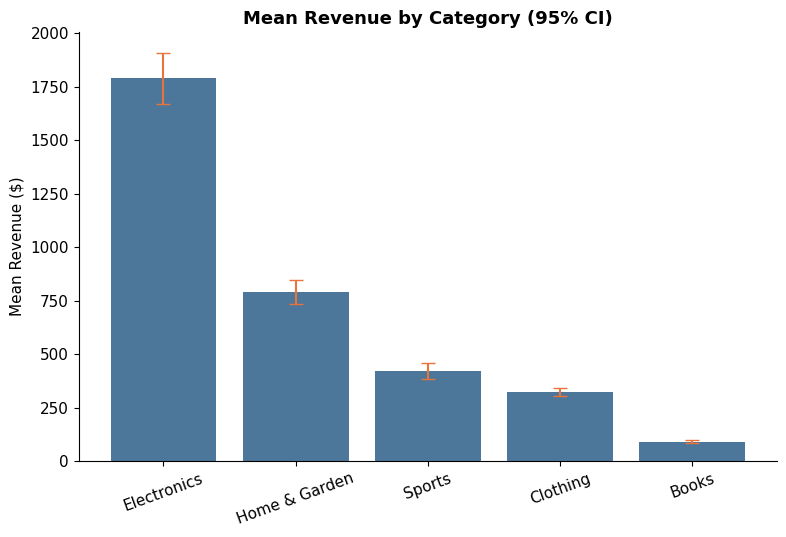

In [20]:
cats_ci = df.groupby('Category')['Revenue'].agg(['mean', 'sem', 'count']).sort_values('mean', ascending=False)
cats_ci['moe'] = cats_ci['sem'] * stats.t.ppf(0.975, cats_ci['count']-1)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.bar(cats_ci.index, cats_ci['mean'], yerr=cats_ci['moe'], capsize=5, color=PALETTE[0], alpha=0.85,
       error_kw={'elinewidth': 1.5, 'ecolor': PALETTE[1]})
ax.set_title('Mean Revenue by Category (95% CI)')
ax.set_ylabel('Mean Revenue ($)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('figures/06_mean_revenue_by_category_ci.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The overall mean revenue per order is **$774.19 ± $43.58** (95% CI: $730.61 – $817.76) — we can be 95% confident the true population mean order value falls in this range. Channel-level CIs **overlap substantially** (consistent with the ANOVA result in Test 1), while category-level CIs are clearly **non-overlapping** for Electronics vs. every other category — visually confirming Test 2's significant result.

## Day 6 — Regression Analysis

Simple linear regression (Revenue ~ Price) followed by a multiple linear regression (Revenue ~ Price + Quantity + Discount), with diagnostic checks.

In [21]:
X_simple = sm.add_constant(df['Price'])
y = df['Revenue']
model_simple = sm.OLS(y, X_simple).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.701
Method:                 Least Squares   F-statistic:                     4696.
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:39:36   Log-Likelihood:                -15431.
No. Observations:                2000   AIC:                         3.087e+04
Df Residuals:                    1998   BIC:                         3.088e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.4142     16.551      0.206      0.8

**Simple model:** Revenue = 3.41 + 2.875 × Price, **R² = 0.701** — Price alone explains 70% of revenue variance. Each additional $1 in price is associated with ~$2.88 more revenue per order (makes sense: Revenue = Price × Quantity, so the slope approximates average quantity purchased).

In [22]:
X_multi = sm.add_constant(df[['Price', 'Quantity', 'Discount']])
model_multi = sm.OLS(y, X_multi).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     3445.
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:39:36   Log-Likelihood:                -14819.
No. Observations:                2000   AIC:                         2.965e+04
Df Residuals:                    1996   BIC:                         2.967e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -739.2448     23.392    -31.603      0.0

In [23]:
vif_data = pd.DataFrame()
vif_data['feature'] = X_multi.columns
vif_data['VIF'] = [variance_inflation_factor(X_multi.values, i) for i in range(X_multi.shape[1])]
print("Variance Inflation Factors (multicollinearity check):")
print(vif_data)
print("\nAll VIFs near 1 (excluding the intercept) -> no meaningful multicollinearity between predictors.")

Variance Inflation Factors (multicollinearity check):
    feature   VIF
0     const 6.837
1     Price 1.001
2  Quantity 1.000
3  Discount 1.001

All VIFs near 1 (excluding the intercept) -> no meaningful multicollinearity between predictors.


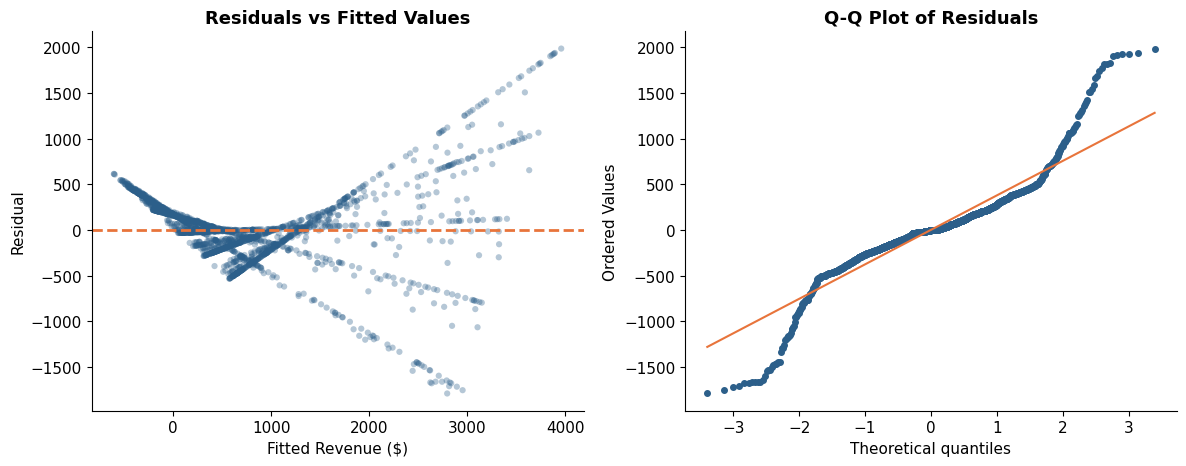

In [24]:
fitted = model_multi.fittedvalues
resid = model_multi.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(fitted, resid, alpha=0.35, s=20, color=PALETTE[0], edgecolors='none')
axes[0].axhline(0, color=PALETTE[1], linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs Fitted Values'); axes[0].set_xlabel('Fitted Revenue ($)'); axes[0].set_ylabel('Residual')

stats.probplot(resid, dist='norm', plot=axes[1])
axes[1].get_lines()[0].set_color(PALETTE[0]); axes[1].get_lines()[0].set_markersize(4)
axes[1].get_lines()[1].set_color(PALETTE[1])
axes[1].set_title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.savefig('figures/07_regression_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

**Multiple regression model:** Revenue = −739.24 + 2.867×Price + 258.02×Quantity − 738.01×Discount

- **R² = 0.838, Adjusted R² = 0.838** — adding Quantity and Discount lifts explained variance from 70% to 84%.
- All three predictors are statistically significant (p < 0.001).
- **Discount's negative coefficient (−738)** confirms deeper discounts are associated with lower revenue per order in this dataset — consistent with the weak negative correlation found in Day 3.
- VIFs ≈ 1.0 for all predictors → no multicollinearity concern; each variable contributes independent explanatory power.
- Residual diagnostics show some right-skew/heavy tails (consistent with Revenue's non-normality from Day 2) — coefficient estimates remain valid (OLS doesn't require normal residuals for unbiasedness), but prediction intervals for individual orders should be interpreted with caution. A log-transformed model would be a natural next step for individual-order prediction.

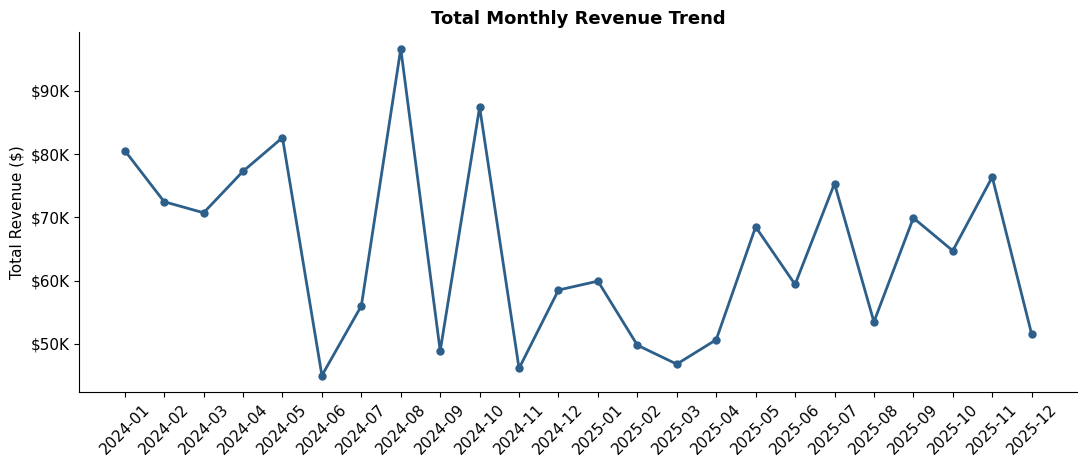

In [25]:
monthly = df.groupby(df['OrderDate'].dt.to_period('M'))['Revenue'].sum()
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(monthly.index.astype(str), monthly.values, marker='o', color=PALETTE[0], linewidth=2, markersize=5)
ax.set_title('Total Monthly Revenue Trend')
ax.set_ylabel('Total Revenue ($)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('figures/08_monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()